<a href="https://colab.research.google.com/github/Andrews-Osei/Plant_disease/blob/main/New_plant_disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import subprocess
import zipfile

# ---------------------------------------------------------
# 0. ENVIRONMENT SETUP & DATASET DOWNLOAD
# ---------------------------------------------------------
# Automatically setup Kaggle and download data if it doesn't exist
if not os.path.exists("dataset"):
    print("Dataset not found. Setting up Kaggle and downloading...")

    # Setup Kaggle API credentials
    kaggle_dir = os.path.expanduser('~/.kaggle')
    os.makedirs(kaggle_dir, exist_ok=True)

    # Prompt for kaggle.json upload if not already in the workspace
    if not os.path.exists('kaggle.json'):
        print("kaggle.json not found! Prompting for upload from your PC...")
        try:
            from google.colab import files
            uploaded = files.upload()
        except ImportError:
            raise FileNotFoundError("Not running in Colab. Please place 'kaggle.json' in the current directory manually.")

    if os.path.exists('kaggle.json'):
        os.system(f'cp kaggle.json {kaggle_dir}/')
        os.chmod(f'{kaggle_dir}/kaggle.json', 0o600)
        print("Kaggle API key configured successfully.")
    else:
        raise FileNotFoundError("kaggle.json upload failed or was cancelled. Please try again.")

    # Download dataset using Kaggle CLI via subprocess
    print("Downloading dataset from Kaggle (this may take a few minutes)...")
    subprocess.run(['kaggle', 'datasets', 'download', '-d', 'vipoooool/new-plant-diseases-dataset'], check=True)

    # Unzip dataset
    print("Extracting dataset...")
    with zipfile.ZipFile('new-plant-diseases-dataset.zip', 'r') as zip_ref:
        zip_ref.extractall('dataset/')
    print("Extraction complete!")
else:
    print("Dataset already exists. Skipping download.")

# ---------------------------------------------------------
# 1. CONFIGURATION & HYPERPARAMETERS
# ---------------------------------------------------------
DATASET_DIR = "dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VALID_DIR = os.path.join(DATASET_DIR, "valid")

IMG_SIZE = (224, 224)
BATCH_SIZE = 16 # Reduced from 32 to prevent Out of Memory (OOM) crashes
EPOCHS = 15 # Adjust based on time/compute availability


Dataset not found. Setting up Kaggle and downloading...
kaggle.json not found! Prompting for upload from your PC...


Saving kaggle.json to kaggle.json
Kaggle API key configured successfully.
Extracting dataset...
Extraction complete!


In [2]:
# ---------------------------------------------------------
# 2. DATA LOADING & PREPROCESSING
# ---------------------------------------------------------
print("Loading training data...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    shuffle=True, # This efficiently shuffles filenames on disk
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("Loading validation data...")
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    shuffle=True,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Extract and save class names for the Streamlit app
class_names = train_dataset.class_names
with open('class_names.json', 'w') as f:
    json.dump(class_names, f)
print(f"Saved {len(class_names)} class names to class_names.json")

# Optimize datasets for performance (prefetching)
# 1. Removed .shuffle(1000) because loading 1000 batches into RAM causes the 12GB memory crash.
# 2. Changed AUTOTUNE to a fixed integer (2) to tightly control memory buffering.
train_dataset = train_dataset.prefetch(buffer_size=2)
validation_dataset = validation_dataset.prefetch(buffer_size=2)


Loading training data...
Found 70295 files belonging to 38 classes.
Loading validation data...
Found 17572 files belonging to 38 classes.
Saved 38 class names to class_names.json


In [3]:
# ---------------------------------------------------------
# 3. DATA AUGMENTATION
# ---------------------------------------------------------
# We implement data augmentation as a sequential layer inside the model pipeline
# This ensures it only runs during training and is saved with the model if desired.
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

In [4]:
# ---------------------------------------------------------
# 4. CNN MODEL DEVELOPMENT
# ---------------------------------------------------------
print("Building CNN Model...")
model = models.Sequential([
    layers.InputLayer(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    data_augmentation,

    # Normalize pixel values from [0, 255] to [0, 1]
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 4
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Classifier Head
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5), # Dropout for regularization
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

model.summary()

Building CNN Model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,673,382 (25.46 MB)

 Trainable params: 6,673,382 (25.46 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# ---------------------------------------------------------
# 5. MODEL TRAINING
# ---------------------------------------------------------
print("Starting training...")

# Custom callback to force Python to clear RAM after each epoch
import gc
class GarbageCollectorCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        gc.collect()

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=[GarbageCollectorCallback()]
)


Starting training...
Epoch 1/15
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 175s 38ms/step - accuracy: 0.3772 - loss: 2.1437 - val_accuracy: 0.6547 - val_loss: 1.0818
Epoch 2/15
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 197s 38ms/step - accuracy: 0.6831 - loss: 1.0191 - val_accuracy: 0.8046 - val_loss: 0.5946
Epoch 3/15
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 169s 38ms/step - accuracy: 0.7673 - loss: 0.7317 - val_accuracy: 0.8140 - val_loss: 0.5913
Epoch 4/15
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 167s 38ms/step - accuracy: 0.8097 - loss: 0.6008 - val_accuracy: 0.8864 - val_loss: 0.3562
Epoch 5/15
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 169s 39ms/step - accuracy: 0.8337 - loss: 0.5239 - val_accuracy: 0.8697 - val_loss: 0.4211
Epoch 6/15
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 171s 39ms/step - accuracy: 0.8491 - loss: 0.4734 - val_accuracy: 0.8844 - val_loss: 0.3687
Epoch 7/15
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 170s 39ms/step - accuracy: 0.8626 - loss: 0.4364 - val_accuracy: 0.9147 - val_loss: 0.2611
Epoch 8/15
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 169s 3

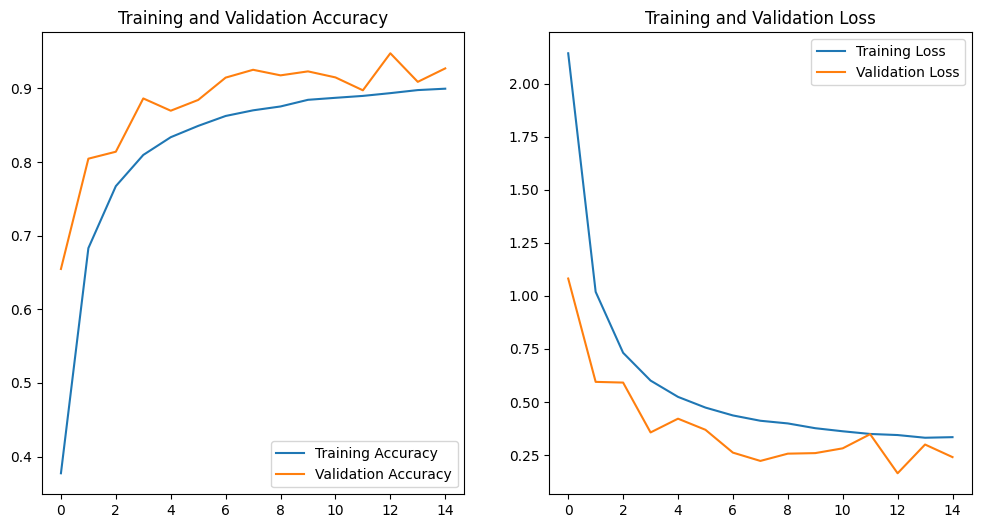

Generating sample predictions...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step


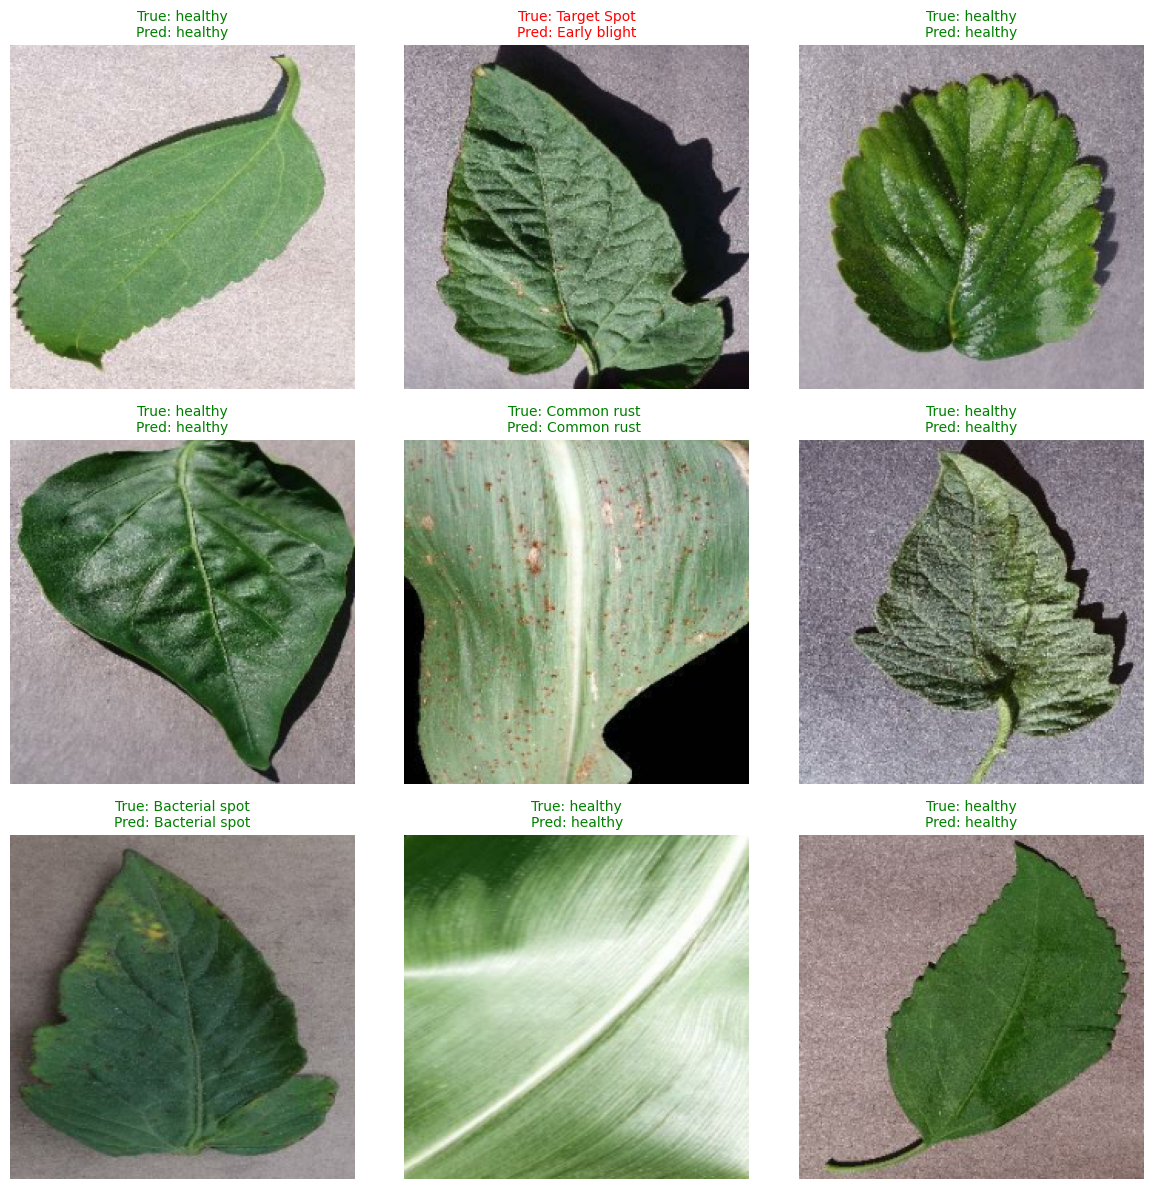

In [6]:
# ---------------------------------------------------------
# 6. EVALUATION & VISUALIZATION
# ---------------------------------------------------------
def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(EPOCHS)

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')

    plt.savefig("training_history.png")
    plt.show()

plot_training_history(history)

def visualize_predictions(dataset, model, class_names, num_images=9):
    print("Generating sample predictions...")
    plt.figure(figsize=(12, 12))
    # Take one batch from the dataset
    for images, labels in dataset.take(1):
        # Generate predictions for the batch
        predictions = model.predict(images)
        predicted_classes = np.argmax(predictions, axis=1)

        # Plot up to num_images
        for i in range(min(num_images, len(images))):
            ax = plt.subplot(3, 3, i + 1)
            # Images need to be cast to uint8 for matplotlib to display correctly
            plt.imshow(images[i].numpy().astype("uint8"))

            true_label = class_names[labels[i]]
            pred_label = class_names[predicted_classes[i]]

            # Green text if correct, red if incorrect
            color = "green" if true_label == pred_label else "red"

            # Format text nicely (removing the plant name prefix for cleaner display if it's too long)
            display_true = true_label.split('___')[-1].replace('_', ' ')
            display_pred = pred_label.split('___')[-1].replace('_', ' ')

            plt.title(f"True: {display_true}\nPred: {display_pred}", color=color, fontsize=10)
            plt.axis("off")

    plt.tight_layout()
    plt.savefig("sample_predictions.png")
    plt.show()

visualize_predictions(validation_dataset, model, class_names)


In [7]:
# ---------------------------------------------------------
# 7. SAVE MODEL & METADATA
# ---------------------------------------------------------
model_save_path = "plant_disease_cnn_model.keras"
model.save(model_save_path)
print(f"Model successfully saved to {model_save_path}")
print("Training Pipeline Complete! Download 'plant_disease_cnn_model.keras' and 'class_names.json' for the Streamlit App.")

Model successfully saved to plant_disease_cnn_model.keras
Training Pipeline Complete! Download 'plant_disease_cnn_model.keras' and 'class_names.json' for the Streamlit App.
